In [5]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Just getting used to the adata data object. It has 3 main components, .obs, .var, and .X. 
.X is a 700 X 765 cell by gene matrix containing expression values.
.obs is a dataframe containing information on all 700 cells. 
.var is a dataframe containing information on all 765 genes.

In [6]:
adata = sc.datasets.pbmc68k_reduced()
adata.X
adata.var.head()
adata.X[:5, :5]
adata.obs["bulk_labels"].value_counts()
adata.varm["PCs"].shape
adata.obsm.keys()

KeysView(AxisArrays with keys: X_pca, X_umap)

Lets try and get a PC plot. Scanpy already is ready to create a PC plot from the adata object. Just need to color based on column from the .obs df. 

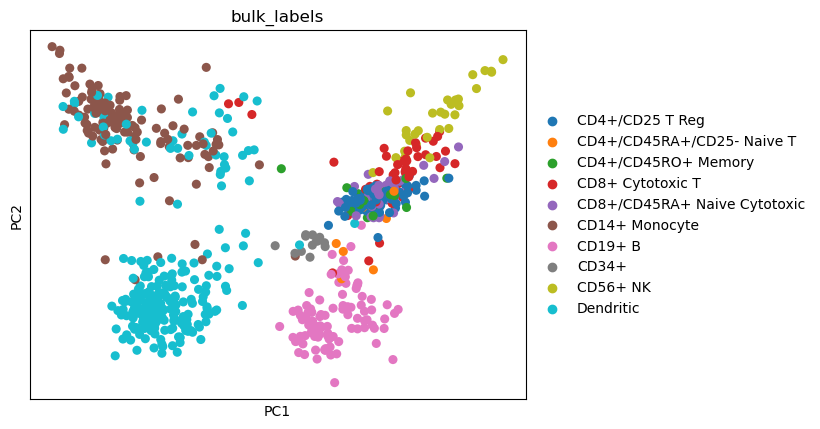

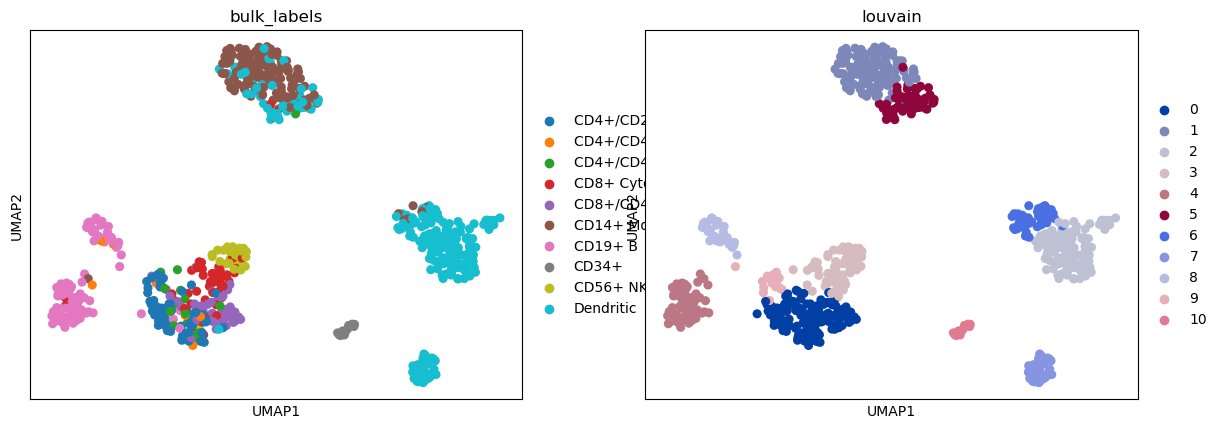

index
PTPRCAP    0.136449
CD3D       0.101292
CD3E       0.098343
CD7        0.095807
CD27       0.095098
AES        0.093681
CD52       0.092849
GZMM       0.092047
LAT        0.091794
IL32       0.090363
dtype: float64

In [7]:
sc.pl.pca(adata, color="bulk_labels")
sc.pl.umap(adata, color=["bulk_labels", "louvain"])
#what genes contributed to PC1 sepparation. We can extract their loading components. 

pc1 = pd.Series(
    adata.varm["PCs"][:, 0],
    index=adata.var_names
)

pc1.sort_values(ascending=False).head(10)

Ok now lets get insight into how many cell types we are dealing with

In [8]:
print(adata.obs["bulk_labels"].value_counts())
print(adata.obs["bulk_labels"].nunique()) # 10 unique cell types

bulk_labels
Dendritic                       240
CD14+ Monocyte                  129
CD19+ B                          95
CD4+/CD25 T Reg                  68
CD8+ Cytotoxic T                 54
CD8+/CD45RA+ Naive Cytotoxic     43
CD56+ NK                         31
CD4+/CD45RO+ Memory              19
CD34+                            13
CD4+/CD45RA+/CD25- Naive T        8
Name: count, dtype: int64
10


Now lets import torch and begin readying data for pytorch. X needs to be converted to a tensor and y needs to be converted to intergers. 

In [117]:
adata = sc.datasets.pbmc68k_reduced()

## Get the gene expression counts as X and the cell labels as y
X_numpy = adata.X
y_series = adata.obs["bulk_labels"]

## Transform X to a tensor object. Convert y string labels to integers
X_tensor = torch.tensor(X_numpy, dtype = torch.float32)


label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_series)
#print(label_encoder.classes_)
#print(y_encoded[:10])

## Now convert encoded y names to a tensor. we use torch.long to represent 64 bit (integers) vs floats
y_tensor = torch.tensor(y_encoded, dtype = torch.long)


## Now we save data and move onto training
torch.save({ "X": X_tensor,"y": y_tensor,}, "../data/processed_data.pt")


Ok great. We not have the tensor of the gene expression data as well as the encoded cell labels. The next step is to create a dataset/dataloader. I will need to create a dataset object with attributes of my dataset. After creating these lets move to training notebook to improve model.